In [1]:
DIR_INPUT = './output_fig'
DIR_OUTPUT = './output_fig'

## Model performance

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

ds_name = 'markov_32feat_11t5g_more_balanced_largeN_censor'
df_metric_makrov_censor_large = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric.csv'), 
    index_col=0
)
df_metric_makrov_censor_large['model_type'] = df_metric_makrov_censor_large['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_makrov_censor_large = df_metric_makrov_censor_large.loc[
    ~df_metric_makrov_censor_large['model_type'].str.contains('Coxnet'),:
]
df_metric_makrov_censor_large['ds_name'] = 'Sim-Main'
df_metric_makrov_censor_large['ds_name_code'] = ds_name



ds_name = 'markov_32feat_11t5g_less_balanced'
df_metric_makrov_censor_imbalance = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric.csv'), 
    index_col=0
)
df_metric_makrov_censor_imbalance['model_type'] = df_metric_makrov_censor_imbalance['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_makrov_censor_imbalance = df_metric_makrov_censor_imbalance.loc[
    ~df_metric_makrov_censor_imbalance['model_type'].str.contains('Coxnet'),:
]
df_metric_makrov_censor_imbalance['descriptor'] = df_metric_makrov_censor_imbalance['descriptor'].replace('SurvSurfTaddTG_dydg','LossDyDg')
df_metric_makrov_censor_imbalance['ds_name'] = 'Sim-LackProg'
df_metric_makrov_censor_imbalance['ds_name_code'] = ds_name


ds_name = 'house_price_traj'
df_metric_house_price = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric.csv'), 
    index_col=0
)
df_metric_house_price['model_type'] = df_metric_house_price['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_house_price = df_metric_house_price.loc[
    ~df_metric_house_price['model_type'].str.contains('Coxnet'),:
]
df_metric_house_price['ds_name'] = 'RW-Property'
df_metric_house_price['ds_name_code'] = ds_name


ds_name = 'real_NCT00981058_inject'
df_metric_trial = pd.read_csv(
    os.path.join(DIR_INPUT, f'{ds_name}_df_model_to_metric.csv'), 
    index_col=0
)
df_metric_trial['model_type'] = df_metric_trial['model_type'].apply(
    lambda x: x.replace('Joint_','')
)
df_metric_trial = df_metric_trial.loc[
    ~df_metric_trial['model_type'].str.contains('Coxnet'),:
]
df_metric_trial['ds_name'] = 'RW-TRAE'
df_metric_trial['ds_name_code'] = ds_name


In [3]:
df_metric_makrov_censor_large['descriptor'].unique()

array(['LossDyDg', 'LossSumo', 'LossSumo(more g)', 'standard',
       'standard(more g)'], dtype=object)

In [4]:
df_metric_makrov_censor_large['model_type'].value_counts()

model_type
DeepHit                             15
GradientBoostingSurvivalAnalysis    10
RandomSurvivalForest                10
SurvSurf2DTaddTGNormTG               5
CoxPHSurvivalAnalysis                1
Name: count, dtype: int64

In [5]:
df_metric_makrov_censor_imbalance['model_type'].value_counts()

model_type
DeepHit                             15
GradientBoostingSurvivalAnalysis    10
RandomSurvivalForest                10
SurvSurf2DTaddTGNormTG               5
CoxPHSurvivalAnalysis                1
Name: count, dtype: int64

In [6]:
set(df_metric_makrov_censor_large.columns) == set(df_metric_makrov_censor_imbalance.columns)

True

In [7]:
df_metric_makrov_censor_large.columns

Index(['run_id', 'model_type', 'intrg_brier_ipcw_by_subj',
       'mean_auc_ipcw_by_subj', 'intrg_brier_ipcw_by_g', 'mean_auc_ipcw_by_g',
       'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'intrg_brier_intrvl_imputed',
       'intrg_mse_certain_obs_ipcw_by_sbj', 'intrg_mse_certain_obs', 'mse',
       'mae', 'descriptor', 'median_prop_t_violated', 'median_max_violation',
       'max_prop_t_violated', 'max_max_violation', 'ds_name', 'ds_name_code'],
      dtype='object')

/tmp/ipykernel_27705/4070139466.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_27705/4070139466.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


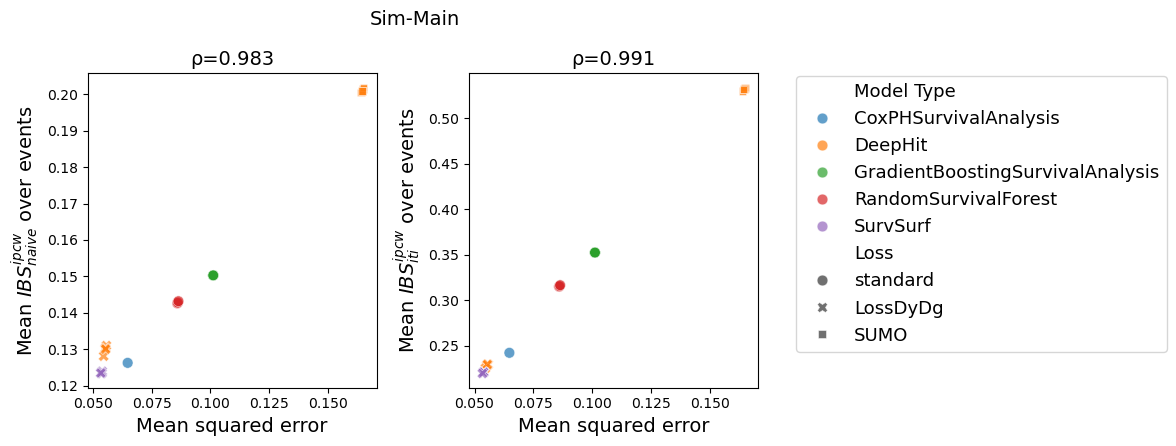

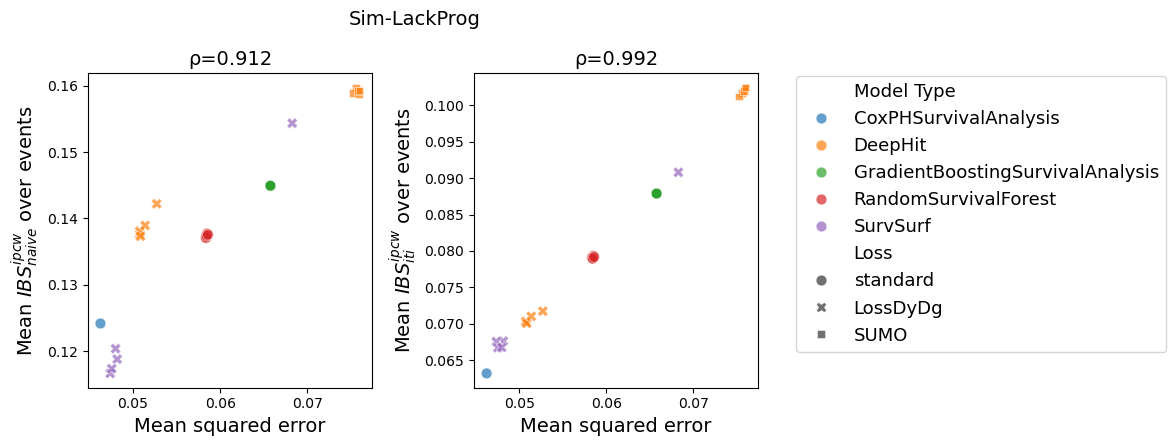

In [8]:
from scipy.stats import spearmanr

xy_fontsize = 14
for df, title in [
    (df_metric_makrov_censor_large, 'Sim-Main'),
    (df_metric_makrov_censor_imbalance, 'Sim-LackProg'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
    axes = axes.flatten()
    counter = 0
    for col_y, col_y_pretty, ax in [
        ('intrg_brier_ipcw_by_subj', 'Mean $IBS^{ipcw}_{naive}$ over events', axes[0]),
        ('intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events', axes[1]),
    ]:
        counter += 1
        col_hue = 'Model Type'
        col_style = 'Loss'
        col_x = 'mse'

        df_plot = df.copy()
        df_plot = df_plot.loc[
            df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
            (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
        ]
        df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
        df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

        df_plot.loc[
            df_plot['max_prop_t_violated'] == 0,
            ['median_max_violation', 'max_max_violation']
        ] = 0
        df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
        df_plot = df_plot.sort_values([col_hue, col_style])

        sns.scatterplot(
            data=df_plot,
            x=col_x,
            y=col_y,
            hue=col_hue,
            style=col_style,
            ax=ax,
            s=60,
            lw=0.5,
            alpha=0.7
        )

        if counter < 2:
            plt.legend().remove()
            ax.legend().remove()
        else:
            plt.legend(bbox_to_anchor = [1.1, 1.02], fontsize=xy_fontsize-1)
        
        corr = spearmanr(df_plot[col_x], df_plot[col_y])[0]
        
        ax.set_xlabel('Mean squared error', fontsize=xy_fontsize)
        ax.set_ylabel(col_y_pretty, fontsize=xy_fontsize)
        ax.set_title(f'ρ={corr:.3g}', fontsize=xy_fontsize)
    ds_name = df['ds_name_code'].iloc[0]
    fig.suptitle(title, x=0.35, fontsize=xy_fontsize)
    fig.tight_layout()
    fig.savefig(os.path.join(DIR_OUTPUT, f'MSE_vs_IBS_all_{ds_name}.pdf'), bbox_inches="tight")

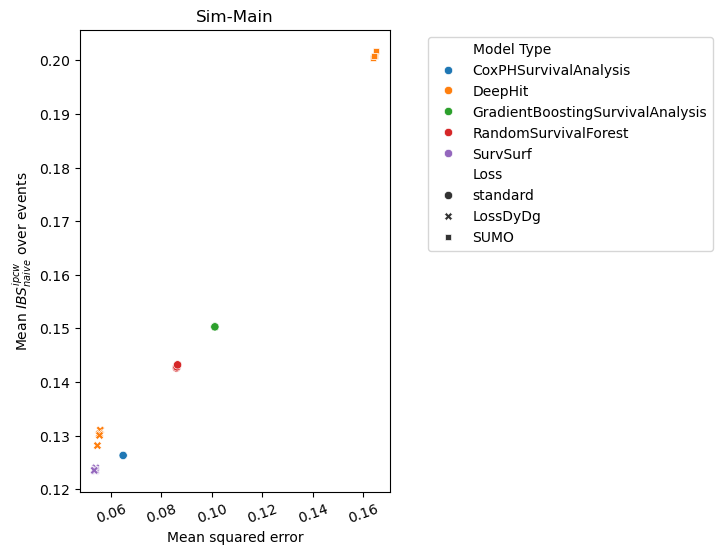

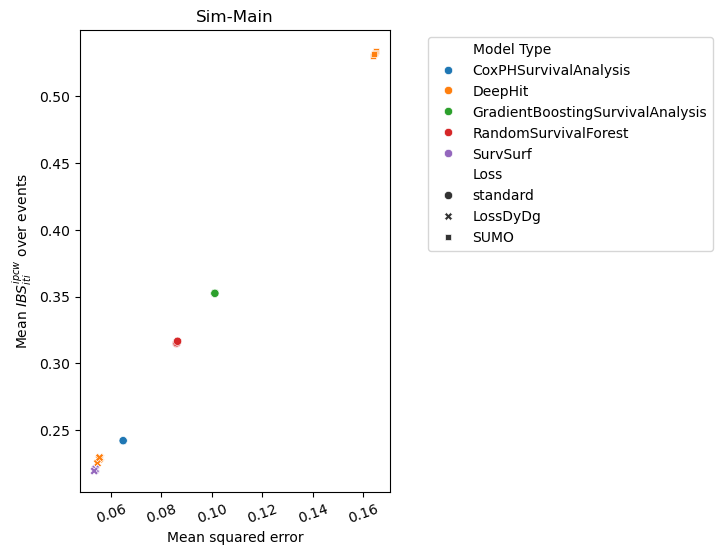

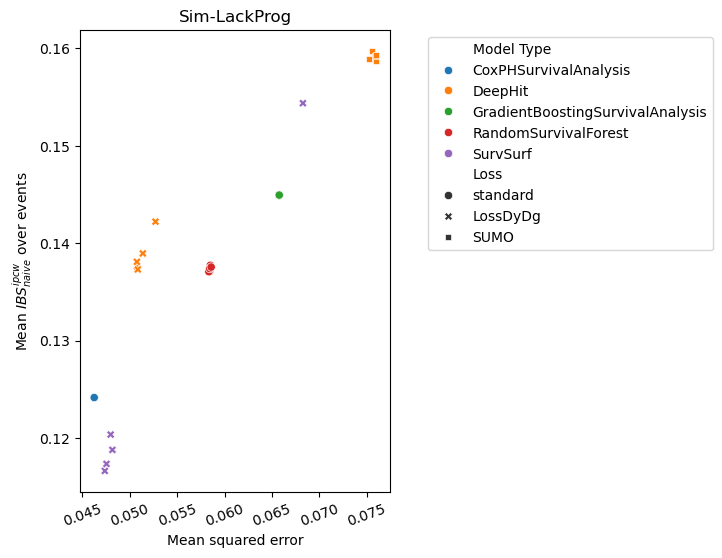

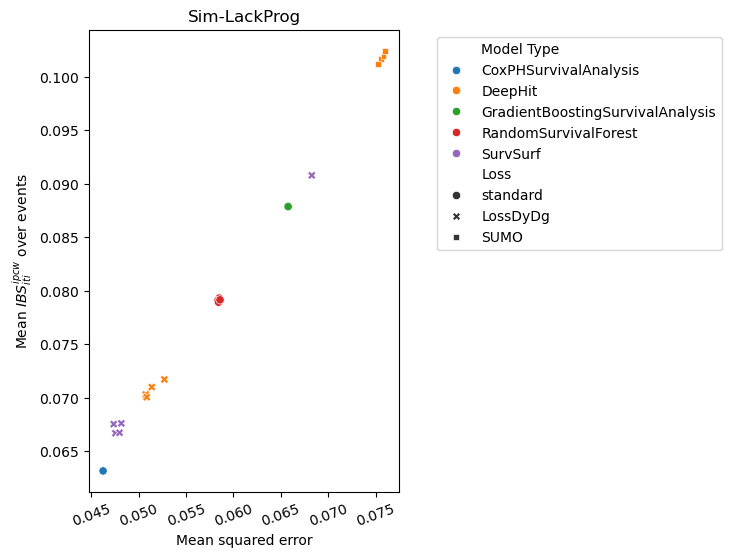

In [9]:
for df, col_y, col_y_pretty, title in [
    (df_metric_makrov_censor_large, 'intrg_brier_ipcw_by_subj', 'Mean $IBS^{ipcw}_{naive}$ over events','Sim-Main'),
    (df_metric_makrov_censor_large, 'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','Sim-Main'),
    (df_metric_makrov_censor_imbalance, 'intrg_brier_ipcw_by_subj', 'Mean $IBS^{ipcw}_{naive}$ over events','Sim-LackProg'),
    (df_metric_makrov_censor_imbalance, 'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','Sim-LackProg'),
]:
    col_hue = 'Model Type'
    col_style = 'Loss'
    col_x = 'mse'

    df_plot = df.copy()
    df_plot = df_plot.loc[
        df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
        (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
    ]
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
    df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

    df_plot.loc[
        df_plot['max_prop_t_violated'] == 0,
        ['median_max_violation', 'max_max_violation']
    ] = 0
    df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
    df_plot = df_plot.sort_values([col_hue, col_style])

    fig, ax = plt.subplots(1,1, figsize=(4, 6))
    sns.scatterplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue=col_hue,
        style=col_style,
        ax=ax
    )
    plt.xticks(rotation=20)
    plt.legend(bbox_to_anchor = [1.1 , 1])
    ax.set(ylabel=col_y_pretty, xlabel='Mean squared error', title=title)
    
    ds_name = df_plot['ds_name_code'].iloc[0]
    fig.savefig(os.path.join(DIR_OUTPUT, f'MSE_vs_{col_y}_{ds_name}.pdf'), bbox_inches="tight")

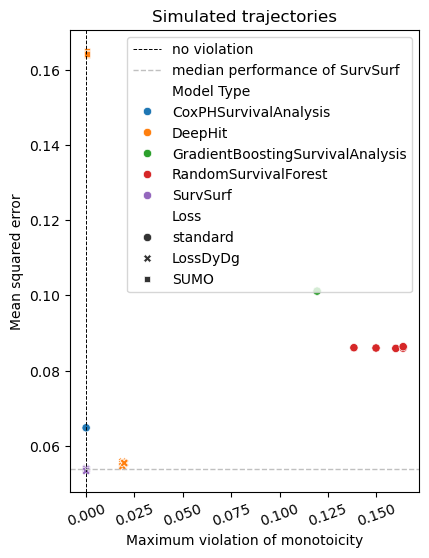

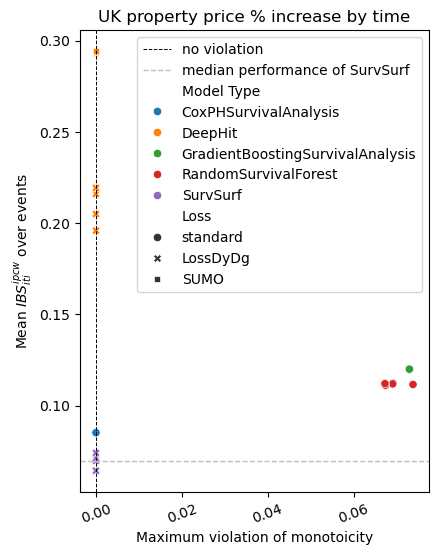

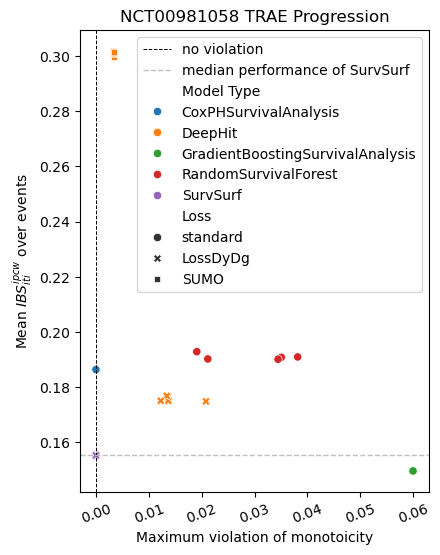

In [10]:
for df, col_y, col_y_pretty, title in [
    (df_metric_makrov_censor_large, 'mse', 'Mean squared error','Simulated trajectories'),
    (df_metric_house_price,'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','UK property price % increase by time'),
    (df_metric_trial,'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','NCT00981058 TRAE Progression')
]:
    col_hue = 'Model Type'
    col_style = 'Loss'
    col_x = 'max_max_violation'

    df_plot = df.copy()
    df_plot = df_plot.loc[
        df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
        (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
    ]
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
    df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

    med_survsurf = df_plot.loc[df_plot['model_type'] == 'SurvSurf',col_y].median()
    df_plot.loc[
        df_plot['max_prop_t_violated'] == 0,
        ['median_max_violation', 'max_max_violation']
    ] = 0
    df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
    df_plot = df_plot.sort_values([col_hue, col_style])

    fig, ax = plt.subplots(1,1, figsize=(4.5, 6))
    ax.axvline(x=0, ls='--', color='black', lw=0.7, label='no violation')
    ax.axhline(y=med_survsurf, ls='--', color='silver', lw=1, label='median performance of SurvSurf')
    sns.scatterplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue=col_hue,
        style=col_style,
        ax=ax
    )
    plt.xticks(rotation=20)
    ax.set(ylabel=col_y_pretty, xlabel='Maximum violation of monotoicity', title=title)
    
    ds_name = df_plot['ds_name_code'].iloc[0]
    fig.savefig(os.path.join(DIR_OUTPUT, f'performance_violation_scatter__{ds_name}.pdf'), bbox_inches="tight")

/tmp/ipykernel_27705/1273209500.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()
/tmp/ipykernel_27705/1273209500.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


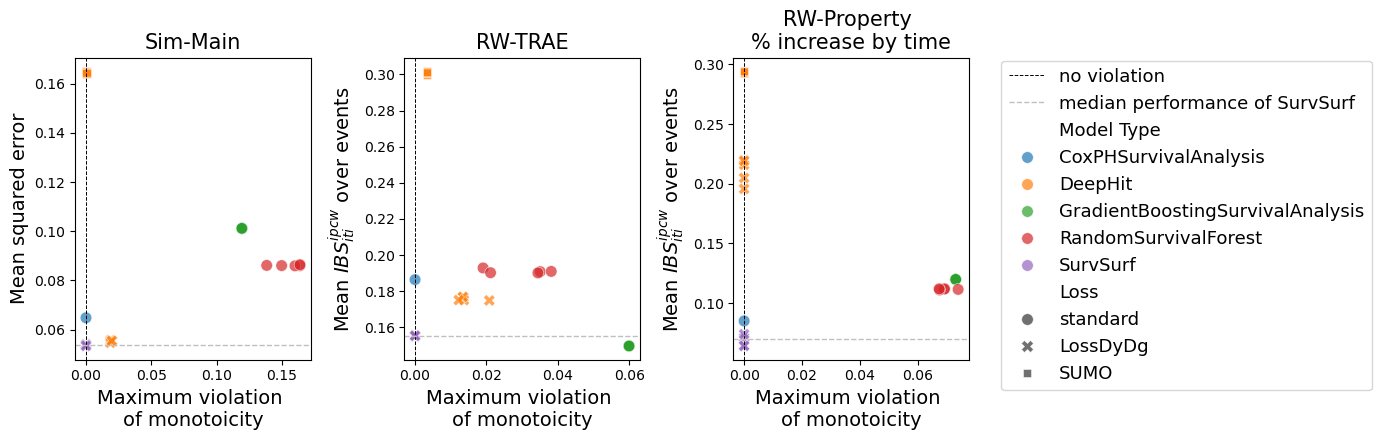

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes = axes.flatten()
xy_fontsize = 14
counter = 0
for df, col_y, col_y_pretty, title, ax in [
    (df_metric_makrov_censor_large, 'mse', 'Mean squared error','Sim-Main', axes[0]),
    (df_metric_trial,'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','RW-TRAE', axes[1]),
    (df_metric_house_price,'intrg_brier_intrvl_imputed_ipcw_by_sbj', 'Mean $IBS^{ipcw}_{iti}$ over events','RW-Property \n% increase by time', axes[2]),
]:
    counter += 1
    col_hue = 'Model Type'
    col_style = 'Loss'
    col_x = 'max_max_violation'

    df_plot = df.copy()
    df_plot = df_plot.loc[
        df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
        (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
    ]
    df_plot['descriptor'] = df_plot['descriptor'].replace('LossSumo','SUMO')
    df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

    med_survsurf = df_plot.loc[df_plot['model_type'] == 'SurvSurf',col_y].median()
    df_plot.loc[
        df_plot['max_prop_t_violated'] == 0,
        ['median_max_violation', 'max_max_violation']
    ] = 0
    df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})
    df_plot = df_plot.sort_values([col_hue, col_style])

    ax.axvline(x=0, ls='--', color='black', lw=0.7, label='no violation')
    ax.axhline(y=med_survsurf, ls='--', color='silver', lw=1, label='median performance of SurvSurf')
    sns.scatterplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue=col_hue,
        style=col_style,
        ax=ax,
        s=70,
        lw=0.5,
        alpha=0.7
    )

    if counter < 3:
        plt.legend().remove()
        ax.legend().remove()
    else:
        plt.legend(bbox_to_anchor = [1.1, 1.02], fontsize=xy_fontsize-1)
    
    ax.set_title(title, fontsize=xy_fontsize+1)
    ax.set_xlabel('Maximum violation \nof monotoicity', fontsize=xy_fontsize)
    ax.set_ylabel(col_y_pretty, fontsize=xy_fontsize)
fig.tight_layout()
fig.savefig(os.path.join(DIR_OUTPUT, f'performance_violation_scatter__all_main_ds.pdf'), bbox_inches="tight")

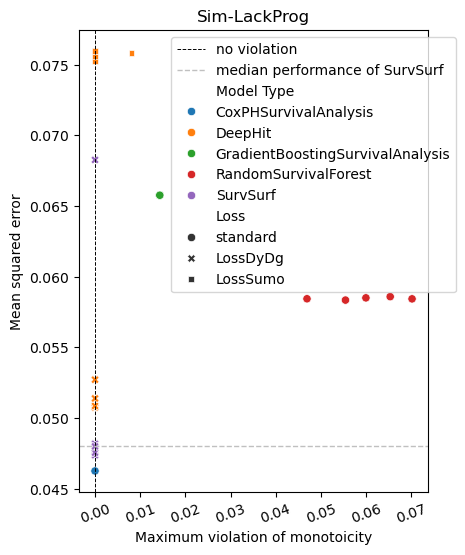

In [12]:
for df, col_y, col_y_pretty, title in [
    (df_metric_makrov_censor_imbalance, 'mse', 'Mean squared error','Sim-LackProg'),

]:
    col_hue = 'Model Type'
    col_style = 'Loss'
    col_x = 'max_max_violation'

    df_plot = df.copy()
    df_plot = df_plot.loc[
        df_plot['descriptor'].isin(['standard', 'LossDyDg', 'LossSumo']) & 
        (df_plot['model_type'] != 'Count_from_train_intvl_imputed'),:
    ]
    df_plot['model_type'] = df_plot['model_type'].replace('SurvSurf2DTaddTGNormTG','SurvSurf')

    med_survsurf = df_plot.loc[df_plot['model_type'] == 'SurvSurf',col_y].median()
    df_plot.loc[
        df_plot['max_prop_t_violated'] == 0,
        ['median_max_violation', 'max_max_violation']
    ] = 0
    df_plot = df_plot.rename(columns={'descriptor':col_style, 'model_type':col_hue})    
    df_plot = df_plot.sort_values([col_hue, col_style])
    
    fig, ax = plt.subplots(1,1, figsize=(4.5, 6))
    ax.axvline(x=0, ls='--', color='black', lw=0.7, label='no violation')
    ax.axhline(y=med_survsurf, ls='--', color='silver', lw=1, label='median performance of SurvSurf')
    sns.scatterplot(
        data=df_plot,
        x=col_x,
        y=col_y,
        hue=col_hue,
        style=col_style,
        ax=ax
    )
    plt.xticks(rotation=20)
    plt.legend(bbox_to_anchor = [1.1 , 1])
    ax.set(ylabel=col_y_pretty, xlabel='Maximum violation of monotoicity', title=title)
    
    ds_name = df_plot['ds_name_code'].iloc[0]
    fig.savefig(os.path.join(DIR_OUTPUT, f'performance_violation_scatter__{ds_name}.pdf'), bbox_inches="tight")


In [13]:
cols_shared = ['run_id','model_type','descriptor','mse','max_prop_t_violated','max_max_violation','ds_name']
df = pd.concat(
    [
        df_metric_makrov_censor_imbalance[cols_shared],
        df_metric_makrov_censor_large[cols_shared]
    ]
)
df = df.loc[
    ~(
        df['descriptor'].str.contains('LossDyDgSumo')|
        df['descriptor'].str.contains('(more g)')
    ),:
]
df['descriptor'] = df['descriptor'].replace('LossSumo','SUMO')

df = df.loc[
    ~df['model_type'].str.contains('Count_from_train_intvl_imputed'),:
]

df.loc[
    df['max_prop_t_violated'] == 0,
    'max_max_violation'
] = 0

df_mse = df.groupby(['ds_name','descriptor', 'model_type'])['mse'].describe()[
    ['count', 'mean', '50%', 'min']
].round(3)
df_mse = df_mse.rename(columns={'50%':'median','count':'N seeds'})
df_mse.columns = [f'MSE({i})' if i != 'N seeds' else i for i in df_mse.columns]
df_violation = df.groupby(['ds_name','descriptor', 'model_type'])['max_max_violation'].describe()[
    ['mean', '50%', 'max']
]


for col in df_violation:
    df_violation[col] = df_violation[col].astype('object')
    df_violation[col] = [ f'{i:.2g}' for i in df_violation[col].values]
df_violation = df_violation.rename(columns={'50%':'median'})
df_violation.columns = [f'maximum monotonicity violation ({i})' for i in df_violation.columns]
df_all = df_mse.join(df_violation).reset_index().rename(
    columns={'ds_name':'Dataset','descriptor':'Loss', 'model_type':'Model type'}
)

df_all.loc[
    df_all['Model type'] == 'SurvSurf2DTaddTGNormTG',
    'Model type'
] = 'SurvSurf'
df_all['N seeds'] = df_all['N seeds'].astype(int)
df_all = df_all.sort_values(['Dataset','Model type','Loss'])
df_all['Model type'] = df_all['Model type'].replace(
    {
        'CoxPHSurvivalAnalysis':'CoxPH',
        'GradientBoostingSurvivalAnalysis':'GBSA',
        'RandomSurvivalForest':'RSF'
    }
)
df_all.to_csv(os.path.join(DIR_OUTPUT, 'df_all_metrics_simulated.csv'), index=False)

/tmp/ipykernel_27705/529112823.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['descriptor'].str.contains('(more g)')


In [14]:
df_all

,Dataset,Loss,Model type,N seeds,MSE(mean),MSE(median),MSE(min),maximum monotonicity violation (mean),maximum monotonicity violation (median),maximum monotonicity violation (max)
3,Sim-LackProg,standard,CoxPH,1,0.046,0.046,0.046,0,0,0
0,Sim-LackProg,LossDyDg,DeepHit,5,0.051,0.051,0.051,0,0,0
2,Sim-LackProg,SUMO,DeepHit,5,0.076,0.076,0.075,0.0016,0,0.0081
4,Sim-LackProg,standard,GBSA,5,0.066,0.066,0.066,0.014,0.014,0.014
5,Sim-LackProg,standard,RSF,5,0.058,0.058,0.058,0.06,0.06,0.07
1,Sim-LackProg,LossDyDg,SurvSurf,5,0.052,0.048,0.047,0,0,0
9,Sim-Main,standard,CoxPH,1,0.065,0.065,0.065,0,0,0
6,Sim-Main,LossDyDg,DeepHit,5,0.055,0.055,0.055,0.019,0.019,0.02
8,Sim-Main,SUMO,DeepHit,5,0.165,0.165,0.164,0.00039,0.00042,0.00043
10,Sim-Main,standard,GBSA,5,0.101,0.101,0.101,0.12,0.12,0.12


In [15]:
cols_shared = ['run_id','model_type','descriptor','intrg_brier_intrvl_imputed_ipcw_by_sbj','max_prop_t_violated','max_max_violation','ds_name']
df = pd.concat(
    [
        df_metric_house_price[cols_shared],
        df_metric_trial[cols_shared]
    ]
)
df = df.loc[
    ~(
        df['descriptor'].str.contains('LossDyDgSumo')|
        df['descriptor'].str.contains('(more g)')
    ),:
]

df = df.loc[
    ~df['model_type'].str.contains('Count_from_train_intvl_imputed'),:
]
df['descriptor'] = df['descriptor'].replace('LossSumo','SUMO')

df.loc[
    df['max_prop_t_violated'] == 0,
    'max_max_violation'
] = 0

df_mse = df.groupby(['ds_name','descriptor', 'model_type'])['intrg_brier_intrvl_imputed_ipcw_by_sbj'].describe()[
    ['count', 'mean', '50%', 'min']
].round(3)
df_mse = df_mse.rename(columns={'50%':'median','count':'N seeds'})
str_ = '$IBS^{ipcw}_{iti}$'
df_mse.columns = [str_ + f'({i})' if i != 'N seeds' else i  for i in df_mse.columns]
df_violation = df.groupby(['ds_name','descriptor', 'model_type'])['max_max_violation'].describe()[
    ['mean', '50%', 'max']
]
for col in df_violation:
    df_violation[col] = df_violation[col].astype('object')
    df_violation[col] = [ f'{i:.2g}' for i in df_violation[col].values]
df_violation = df_violation.rename(columns={'50%':'median'})
df_violation.columns = [f'maximum monotonicity violation ({i})' for i in df_violation.columns]
df_all = df_mse.join(df_violation).reset_index().rename(
    columns={'ds_name':'Dataset','descriptor':'Loss', 'model_type':'Model type'}
)
df_all.loc[
    df_all['Model type'] == 'SurvSurf2DTaddTGNormTG',
    'Model type'
] = 'SurvSurf'
df_all['N seeds'] = df_all['N seeds'].astype(int)
df_all = df_all.sort_values(['Dataset','Model type','Loss'])
df_all['Model type'] = df_all['Model type'].replace(
    {
        'CoxPHSurvivalAnalysis':'CoxPH',
        'GradientBoostingSurvivalAnalysis':'GBSA',
        'RandomSurvivalForest':'RSF'
    }
)
df_all.to_csv(os.path.join(DIR_OUTPUT, 'df_all_metrics_real.csv'), index=False)

/tmp/ipykernel_27705/1920917560.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['descriptor'].str.contains('(more g)')


In [16]:
df_all

,Dataset,Loss,Model type,N seeds,$IBS^{ipcw}_{iti}$(mean),$IBS^{ipcw}_{iti}$(median),$IBS^{ipcw}_{iti}$(min),maximum monotonicity violation (mean),maximum monotonicity violation (median),maximum monotonicity violation (max)
3,RW-Property,standard,CoxPH,1,0.085,0.085,0.085,0,0,0
0,RW-Property,LossDyDg,DeepHit,5,0.211,0.216,0.196,0,0,0
2,RW-Property,SUMO,DeepHit,5,0.293,0.293,0.293,3.7e-06,3.7e-06,4.1e-06
4,RW-Property,standard,GBSA,5,0.120,0.120,0.120,0.073,0.073,0.073
5,RW-Property,standard,RSF,5,0.112,0.112,0.111,0.069,0.069,0.074
1,RW-Property,LossDyDg,SurvSurf,5,0.069,0.070,0.064,0,0,0
9,RW-TRAE,standard,CoxPH,1,0.186,0.186,0.186,0,0,0
6,RW-TRAE,LossDyDg,DeepHit,5,0.176,0.175,0.175,0.015,0.014,0.021
8,RW-TRAE,SUMO,DeepHit,5,0.301,0.301,0.300,0.0033,0.0033,0.0034
10,RW-TRAE,standard,GBSA,5,0.150,0.150,0.150,0.06,0.06,0.06


In [17]:
with open(os.path.join(DIR_OUTPUT, 'df_all_metrics_real_latex.txt'),'w') as out_file:
    with open('./output_fig/df_all_metrics_real.csv','r') as in_file:
        for line in in_file.readlines():
            line_latex = line.replace(',', ' & ').replace('\n', ' \\\\' + '\n')
            out_file.writelines(line_latex)

In [18]:
with open(os.path.join(DIR_OUTPUT,'df_all_metrics_simulated_latex.txt'),'w') as out_file:
    with open('./output_fig/df_all_metrics_simulated.csv','r') as in_file:
        for line in in_file.readlines():
            line_latex = line.replace(',', ' & ').replace('\n', ' \\\\' + '\n')
            out_file.writelines(line_latex)

## SurvSurf feature importance

In [19]:
df_model_to_metric = pd.read_csv('./output_fig/trial_survsurf_feat_perm_perf.csv', index_col=0)
perf_change = df_model_to_metric.loc[
    df_model_to_metric['feat'].notna(), 
    ['feat', 'intrg_brier_intrvl_imputed_ipcw_by_sbj']
]

perf_change['performance degradation when permuted'] = (
    perf_change['intrg_brier_intrvl_imputed_ipcw_by_sbj']
     - df_model_to_metric.loc[df_model_to_metric['feat'].isna(), 'intrg_brier_intrvl_imputed_ipcw_by_sbj'].iloc[0]
)
perf_change['feat'] = perf_change['feat'].str.replace(
    'feat__',''
).str.replace(
    '_',': '
).str.replace(
    ': cat',''
).str.replace(
    'traj: clust','Trajectory Cluster ID'
).str.replace(
    'm^2','$m^2$'
).str.replace(
    '10^9','$10^9$'
).str.replace(
    '>=','$\geq$'
).str.replace(
    'BMIBL','BMI'
).str.replace(
    'BSABL','BSA'
)

perf_change['feat'] = [
    i[0] + i[1:].lower() if 
    ('DISORDERS' in i) or ('CONDITIONS' in i) or ('NEOPLASMS BENIGN' in i) 
    or ('INFECTIONS AND INFESTATIONS' in i)
    or ('PROCEDURES' in i)
    or ('COMPLICATION' in i)
    or ('CIRCUMSTANCES' in i)
    or ('AGE' in i)
    else i for i in perf_change['feat']
]


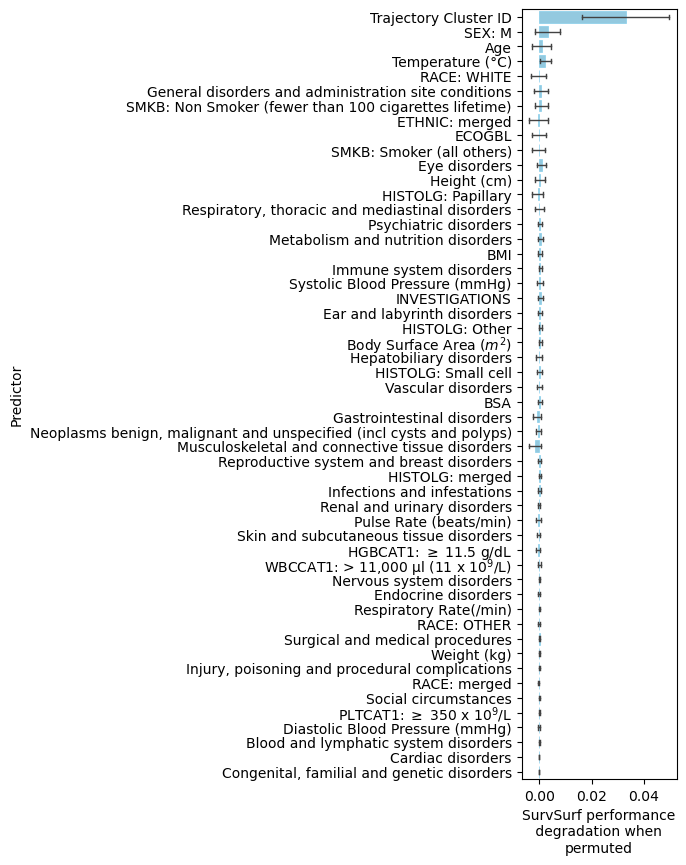

In [20]:
fig, ax = plt.subplots(1,1, figsize=(2, 10))
df_to_plot = perf_change.copy()
df_to_plot = df_to_plot.sort_values('performance degradation when permuted', ascending=False)
sns.barplot(
    data=df_to_plot,
    y='feat',
    x='performance degradation when permuted',
    errorbar=lambda x: (x.mean() - 1.96*x.std(), x.mean() + 1.96*x.std()),
    color='skyblue',
    capsize=0.3,
    err_kws={'lw':1},
    linewidth=0.5,
    edgecolor='skyblue',
    orient='h',
    ax=ax
)
ax.set(xlabel='SurvSurf performance\n degradation when \npermuted', ylabel='Predictor')
fig.savefig('./output_fig/trial_survsurf_feat_perm_perf_change.pdf', bbox_inches='tight')

## RW-property stats

In [21]:
df = pd.read_csv('/home/yc366/repos/survsurf_benchmark/dataset_raw/house_price_traj/df_features.csv', index_col=0)

In [22]:
df['traj_id'].apply(lambda x: x[9:]).unique()

array(['DetachedExisting', 'FlatExisting', 'SemiExisting',
       'TerracedExisting', 'DetachedNew', 'SemiNew', 'TerracedNew',
       'FlatNew'], dtype=object)

In [23]:
df['traj_id'].apply(lambda x: x[:9]).nunique()


322

In [24]:
df['traj_id'].nunique()

2297